# Bella Lui - 3 DOF Flight Simulation and Comparison

This notebook demonstrates a 3 DOF (Degrees of Freedom) flight simulation using the Bella Lui rocket parameters.
We will also compare the results with a 6 DOF simulation to understand the differences between the two approaches.

## Overview
- **3 DOF Simulation**: Models the rocket as a point mass, considering only translational motion (x, y, z).
- **6 DOF Simulation**: Full simulation including rotational dynamics (pitch, yaw, roll).

Permission to use flight data given by Antoine Scardigli, 2020 (EPFL Rocket Team)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Importing libraries
import matplotlib.pyplot as plt
import numpy as np

from rocketpy import Environment, Flight, Function, Rocket, SolidMotor
from rocketpy.rocket import PointMassRocket

In [3]:
plt.style.use("seaborn-v0_8-dark-palette")

## Setting Up Common Parameters

Define a dictionary with the inputs for both simulations

In [4]:
parameters = {
    # Mass Details
    "rocket_mass": (18.227 - 0.001, 0.010),  # propellant mass = 1.373
    # propulsion details
    "impulse": (2157, 0.03 * 2157),
    "burn_time": (2.43, 0.1),
    "nozzle_radius": (44.45 / 1000, 0.001),
    "throat_radius": (21.4376 / 1000, 0.001),
    "grain_separation": (3 / 1000, 1 / 1000),
    "grain_density": (782.4, 30),
    "grain_outer_radius": (85.598 / 2000, 0.001),
    "grain_initial_inner_radius": (33.147 / 1000, 0.002),
    "grain_initial_height": (152.4 / 1000, 0.001),
    # Aerodynamic Details
    "inertia_i": (0.78267, 0.03 * 0.78267),
    "inertia_z": (0.064244, 0.03 * 0.064244),
    "radius": (156 / 2000, 0.001),
    "distance_rocket_nozzle": (-1.1356, 0.100),
    "distance_rocket_propellant": (-1, 0.100),
    "power_off_drag": (1, 0.05),
    "power_on_drag": (1, 0.05),
    "nose_length": (0.242, 0.001),
    "nose_distance_to_cm": (1.3, 0.100),
    "fin_span": (0.200, 0.001),
    "fin_root_chord": (0.280, 0.001),
    "fin_tip_chord": (0.125, 0.001),
    "fin_distance_to_cm": (-0.75, 0.100),
    "tail_top_radius": (156 / 2000, 0.001),
    "tail_bottom_radius": (135 / 2000, 0.001),
    "tail_length": (0.050, 0.001),
    "tail_distance_to_cm": (-1.0856, 0.001),
    # Launch and Environment Details
    "wind_direction": (0, 5),
    "wind_speed": (1, 0.05),
    "inclination": (89, 1),
    "heading": (45, 5),
    "rail_length": (4.2, 0.001),
    # Parachute Details
    "CdS_drogue": (np.pi / 4, 0.20 * np.pi / 4),
    "lag_rec": (1, 0.020),
}

## Environment Setup

Create the Environment object (common to both simulations)

In [5]:
# Environment conditions
env = Environment(
    gravity=9.81,
    latitude=47.213476,
    longitude=9.003336,
    date=(2020, 2, 22, 13),
    elevation=407,
)

env.set_atmospheric_model(
    type="Reanalysis",
    file="../../data/weather/bella_lui_weather_data_ERA5.nc",
    dictionary="ECMWF",
)

env.max_expected_height = 1000


Gravity Details

Acceleration of gravity at surface level:    9.8100 m/s²
Acceleration of gravity at   1.000 km (ASL): 9.8100 m/s²


Launch Site Details

Launch Date: 2020-02-22 13:00:00 UTC
Launch Site Latitude: 47.21348°
Launch Site Longitude: 9.00334°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 500252.61 E    5228887.37 N
Launch Site UTM zone: 32T
Launch Site Surface Elevation: 407.0 m


Atmospheric Model Details

Atmospheric Model Type: Reanalysis
Reanalysis Maximum Height: 1.000 km
Reanalysis Time Period: from 2020-02-22 00:00:00 to 2020-02-22 18:00:00 utc
Reanalysis Hour Interval: 4 hrs
Reanalysis Latitude Range: From 48.0° to 46.0°
Reanalysis Longitude Range: From 8.0° to 10.0°

Surface Atmospheric Conditions

Surface Wind Speed: 1.26 m/s
Surface Wind Direction: 213.21°
Surface Wind Heading: 33.21°
Surface Pressure: 980.43 hPa
Surface Temperature: 286.63 K
Surface Air Density: 1.192 kg/m³
Surface Speed of Sound: 339.39 m/s


Earth Model Details

Earth Radius at Lau

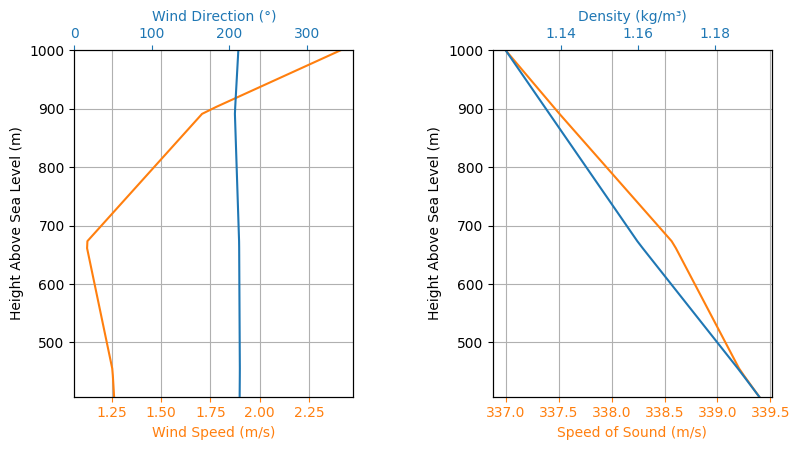

In [6]:
env.info()

## Motor Setup (Common)

Create the motor object to be used in both simulations

Nozzle Details
Nozzle Radius: 0.04445 m
Nozzle Throat Radius: 0.0214376 m

Grain Details
Number of Grains: 3
Grain Spacing: 0.003 m
Grain Density: 782.4 kg/m3
Grain Outer Radius: 0.042799 m
Grain Inner Radius: 0.033146999999999996 m
Grain Height: 0.1524 m
Grain Volume: 0.000 m3
Grain Mass: 0.275 kg

Motor Details
Total Burning Time: 2.43 s
Total Propellant Mass: 0.824 kg
Structural Mass Ratio: 0.001
Average Propellant Exhaust Velocity: 2514.035 m/s
Average Thrust: 852.260 N
Maximum Thrust: 1303.79 N at 0.04 s after ignition.
Total Impulse: 2070.992 Ns



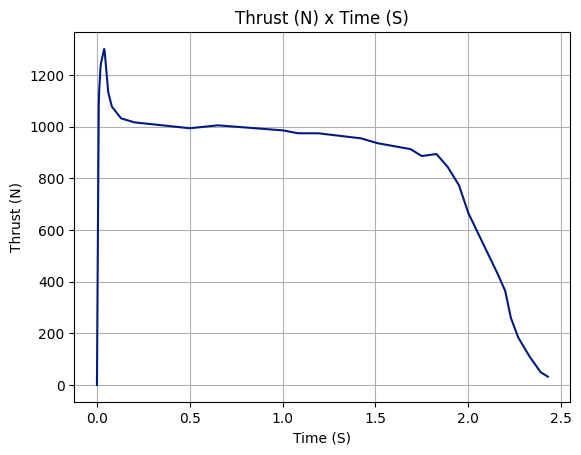

In [7]:
# Define motor
k828fj = SolidMotor(
    thrust_source="../../data/motors/aerotech/AeroTech_K828FJ.eng",
    burn_time=parameters.get("burn_time")[0],
    dry_mass=0.001,
    dry_inertia=(0, 0, 0),
    center_of_dry_mass_position=0.3,
    grains_center_of_mass_position=0.3,
    grain_number=3,
    grain_separation=parameters.get("grain_separation")[0],
    grain_density=parameters.get("grain_density")[0],
    grain_outer_radius=parameters.get("grain_outer_radius")[0],
    grain_initial_inner_radius=parameters.get("grain_initial_inner_radius")[0],
    grain_initial_height=parameters.get("grain_initial_height")[0],
    nozzle_radius=parameters.get("nozzle_radius")[0],
    throat_radius=parameters.get("throat_radius")[0],
    interpolation_method="linear",
    nozzle_position=0,
    coordinate_system_orientation="nozzle_to_combustion_chamber",
)

k828fj.info()

## Part 1: 6 DOF Simulation (Full Rocket Model)

In [8]:
# Create full 6 DOF Rocket object
bella_lui_6dof = Rocket(
    radius=parameters.get("radius")[0],
    mass=parameters.get("rocket_mass")[0],
    inertia=(
        parameters.get("inertia_i")[0],
        parameters.get("inertia_i")[0],
        parameters.get("inertia_z")[0],
    ),
    power_off_drag=0.43,
    power_on_drag=0.43,
    center_of_mass_without_motor=0,
)
bella_lui_6dof.set_rail_buttons(0.1, -0.5)
bella_lui_6dof.add_motor(motor=k828fj, position=parameters.get("distance_rocket_nozzle")[0])

In [9]:
# Add aerodynamic surfaces to 6 DOF rocket
nose_cone_6dof = bella_lui_6dof.add_nose(
    length=parameters.get("nose_length")[0],
    kind="tangent",
    position=parameters.get("nose_distance_to_cm")[0]
    + parameters.get("nose_length")[0],
)
fin_set_6dof = bella_lui_6dof.add_trapezoidal_fins(
    3,
    span=parameters.get("fin_span")[0],
    root_chord=parameters.get("fin_root_chord")[0],
    tip_chord=parameters.get("fin_tip_chord")[0],
    position=parameters.get("fin_distance_to_cm")[0],
)
tail_6dof = bella_lui_6dof.add_tail(
    top_radius=parameters.get("tail_top_radius")[0],
    bottom_radius=parameters.get("tail_bottom_radius")[0],
    length=parameters.get("tail_length")[0],
    position=parameters.get("tail_distance_to_cm")[0],
)

In [10]:
# Add parachute to 6 DOF rocket
Drogue_6dof = bella_lui_6dof.add_parachute(
    "Drogue",
    cd_s=parameters.get("CdS_drogue")[0],
    trigger="apogee",
    sampling_rate=105,
    lag=parameters.get("lag_rec")[0],
    noise=(0, 8.3, 0.5),
)

In [11]:
# Define aerodynamic drag coefficients for 6 DOF
bella_lui_6dof.power_off_drag = Function(
    [
        (0.01, 0.51),
        (0.02, 0.46),
        (0.04, 0.43),
        (0.28, 0.43),
        (0.29, 0.44),
        (0.45, 0.44),
        (0.49, 0.46),
    ],
    "Mach Number",
    "Drag Coefficient with Power Off",
    "linear",
    "constant",
)
bella_lui_6dof.power_on_drag = Function(
    [
        (0.01, 0.51),
        (0.02, 0.46),
        (0.04, 0.43),
        (0.28, 0.43),
        (0.29, 0.44),
        (0.45, 0.44),
        (0.49, 0.46),
    ],
    "Mach Number",
    "Drag Coefficient with Power On",
    "linear",
    "constant",
)
bella_lui_6dof.power_off_drag *= parameters.get("power_off_drag")[0]
bella_lui_6dof.power_on_drag *= parameters.get("power_on_drag")[0]

In [12]:
bella_lui_6dof.info()


Inertia Details

Rocket Mass: 18.226 kg (without motor)
Rocket Dry Mass: 18.227 kg (with unloaded motor)
Rocket Loaded Mass: 19.051 kg
Rocket Structural Mass Ratio: 0.957
Rocket Inertia (with unloaded motor) 11: 0.783 kg*m2
Rocket Inertia (with unloaded motor) 22: 0.783 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.064 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.078 m
Rocket Frontal Area: 0.019113 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.000 m
Rocket Center of Dry Mass - Nozzle Exit: 1.136 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.836 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.036 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 10.281/rad
Tail Lift Coefficient De

In [13]:
# Run 6 DOF Flight simulation
flight_6dof = Flight(
    rocket=bella_lui_6dof,
    environment=env,
    rail_length=parameters.get("rail_length")[0],
    inclination=parameters.get("inclination")[0],
    heading=parameters.get("heading")[0],
)


Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 407.00 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: 1.000 | e1: -0.006 | e2: 0.006 | e3: 0.000
Euler Angles - Spin φ : 45.00° | Nutation θ: -1.00° | Precession ψ: -45.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 2.777 c


Surface Wind Conditions

Frontal Surface Wind Speed: 1.23 m/s
Lateral Surface Wind Speed: 0.26 m/s


Launch Rail

Launch Rail Length: 4.2 m
Launch Rail Inclination: 89.00°
Launch Rail Heading: 45.00°


Rail Departure State

Rail Departure Time: 0.359 s
Rail Departure Velocity: 16.184 m/s
Rail Departure Stability Margin: 2.818 c
Rail Departure Angle of Attack: 4.457°
Rail Departure Thrust-Weight Ratio: 5.416
Rail Departure Reynolds Number: 1.691e+05


Burn out State

Burn out time: 2.430 s
Altitude at burn out: 529.977 m (ASL) | 122.977 m (AGL)
Rocket speed at burn out: 85.172 m/s
Freestream veloci

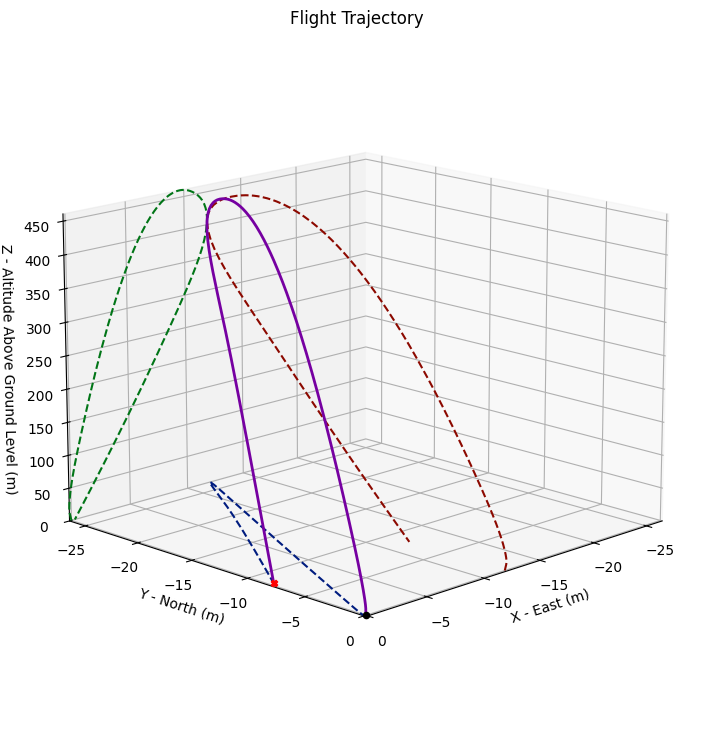

In [14]:
flight_6dof.info()
flight_6dof.plots.trajectory_3d()

## Part 2: 3 DOF Simulation (Point Mass Model)

In 3 DOF mode, the rocket is treated as a point mass, meaning rotational dynamics
(pitch, yaw, roll) are not simulated. This is achieved by using the `PointMassRocket` class.

In [15]:
# Create drag coefficient function for 3 DOF
power_off_drag_3dof = Function(
    [
        (0.01, 0.51),
        (0.02, 0.46),
        (0.04, 0.43),
        (0.28, 0.43),
        (0.29, 0.44),
        (0.45, 0.44),
        (0.49, 0.46),
    ],
    "Mach Number",
    "Drag Coefficient with Power Off",
    "linear",
    "constant",
)
power_on_drag_3dof = Function(
    [
        (0.01, 0.51),
        (0.02, 0.46),
        (0.04, 0.43),
        (0.28, 0.43),
        (0.29, 0.44),
        (0.45, 0.44),
        (0.49, 0.46),
    ],
    "Mach Number",
    "Drag Coefficient with Power On",
    "linear",
    "constant",
)
power_off_drag_3dof *= parameters.get("power_off_drag")[0]
power_on_drag_3dof *= parameters.get("power_on_drag")[0]

In [16]:
# Create 3 DOF Point Mass Rocket
bella_lui_3dof = PointMassRocket(
    radius=parameters.get("radius")[0],
    mass=parameters.get("rocket_mass")[0],
    center_of_mass_without_motor=0,
    power_off_drag=power_off_drag_3dof,
    power_on_drag=power_on_drag_3dof,
)

# Add motor to the 3 DOF rocket
bella_lui_3dof.add_motor(motor=k828fj, position=parameters.get("distance_rocket_nozzle")[0])

In [17]:
# Add parachute to 3 DOF rocket
Drogue_3dof = bella_lui_3dof.add_parachute(
    "Drogue",
    cd_s=parameters.get("CdS_drogue")[0],
    trigger="apogee",
    sampling_rate=105,
    lag=parameters.get("lag_rec")[0],
    noise=(0, 8.3, 0.5),
)

In [18]:
# Display basic 3 DOF rocket info
print("3 DOF Point Mass Rocket")
print(f"Radius: {bella_lui_3dof.radius:.4f} m")
print(f"Mass (without motor): {bella_lui_3dof.mass:.3f} kg")
print(f"Center of mass (without motor): {bella_lui_3dof.center_of_mass_without_motor:.3f} m")

3 DOF Point Mass Rocket
Radius: 0.0780 m
Mass (without motor): 18.226 kg
Center of mass (without motor): 0.000 m


In [19]:
# Run 3 DOF Flight simulation
flight_3dof = Flight(
    rocket=bella_lui_3dof,
    environment=env,
    rail_length=parameters.get("rail_length")[0],
    inclination=parameters.get("inclination")[0],
    heading=parameters.get("heading")[0],
)

/home/runner/work/RocketPy/RocketPy/rocketpy/simulation/flight.py:1246: UserWarning: A point-mass model was detected. Simulation mode should be '3 DOF'.
  warnings.warn(


3 DOF Flight - Apogee: 460.85 m AGL
3 DOF Flight - Time to Apogee: 10.61 s
3 DOF Flight - Max Speed: 86.23 m/s
3 DOF Flight - Impact Point: (31.18, 39.81) m


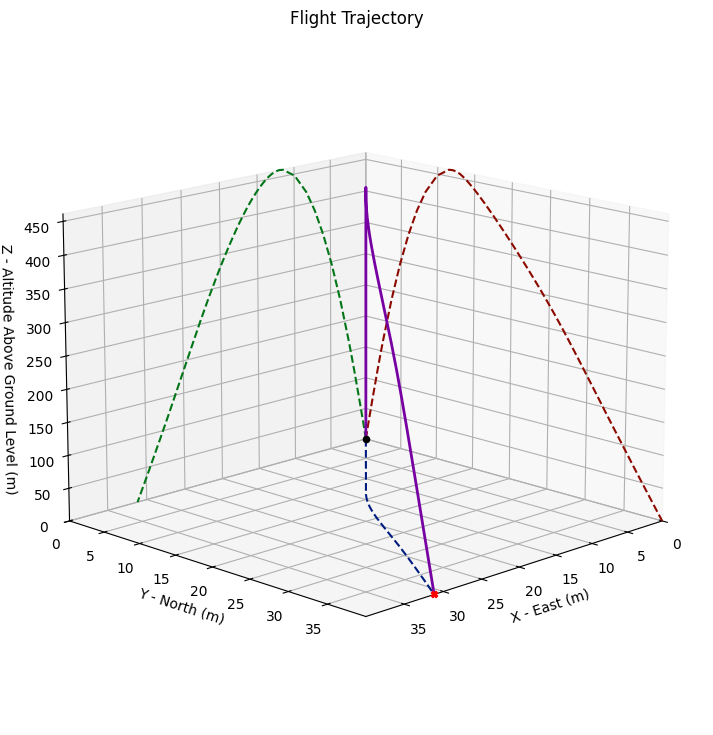

In [20]:
# Note: flight.info() is not fully supported for 3 DOF simulations
# We'll display the 3D trajectory instead
print(f"3 DOF Flight - Apogee: {flight_3dof.apogee - env.elevation:.2f} m AGL")
print(f"3 DOF Flight - Time to Apogee: {flight_3dof.apogee_time:.2f} s")
print(f"3 DOF Flight - Max Speed: {flight_3dof.max_speed:.2f} m/s")
print(f"3 DOF Flight - Impact Point: ({flight_3dof.x_impact:.2f}, {flight_3dof.y_impact:.2f}) m")
flight_3dof.plots.trajectory_3d()

## 3 DOF Simulation Plots

Generate equivalent graphs for the 3 DOF flight simulation

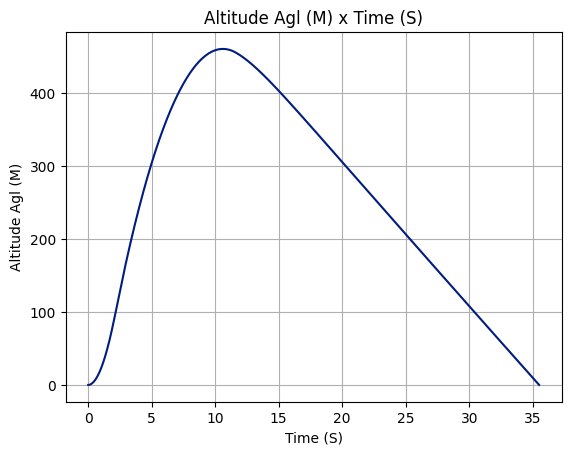

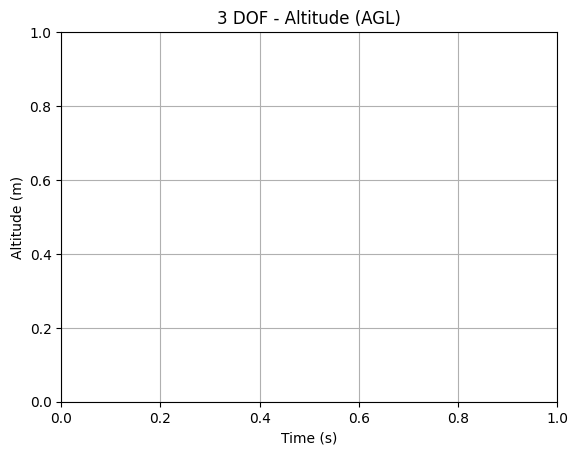

In [21]:
# Altitude over time
flight_3dof.altitude.plot()
plt.title("3 DOF - Altitude (AGL)")
plt.xlabel("Time (s)")
plt.ylabel("Altitude (m)")
plt.grid(True)
plt.show()

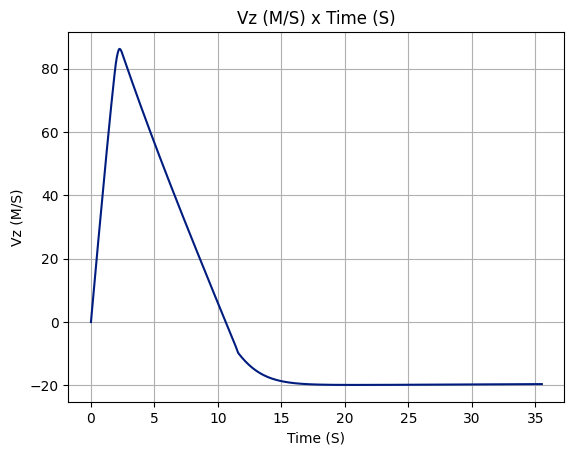

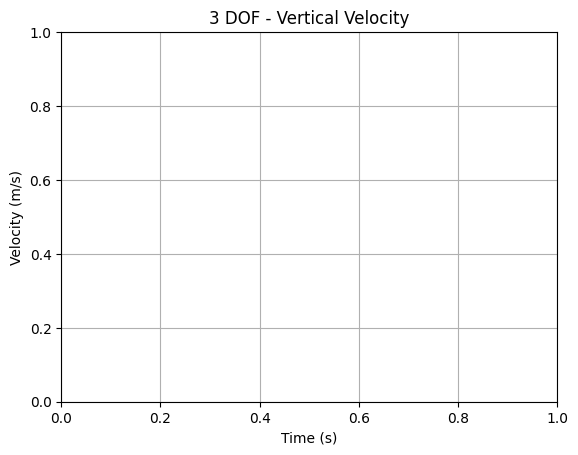

In [22]:
# Vertical velocity over time
flight_3dof.vz.plot()
plt.title("3 DOF - Vertical Velocity")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.grid(True)
plt.show()

In [23]:
# Note: Acceleration properties require post-processing which
# is not fully supported in 3 DOF mode.
# We'll skip the individual acceleration plot for 3 DOF.

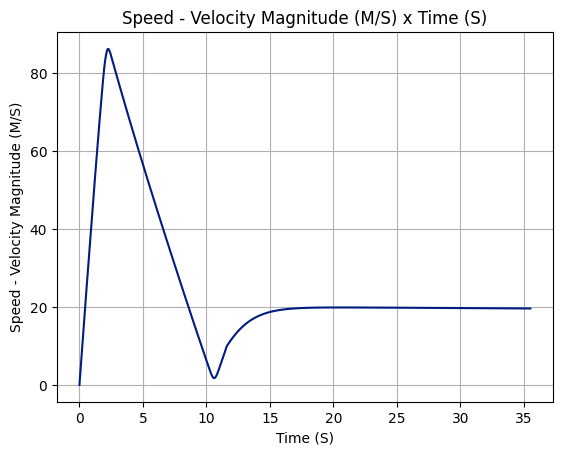

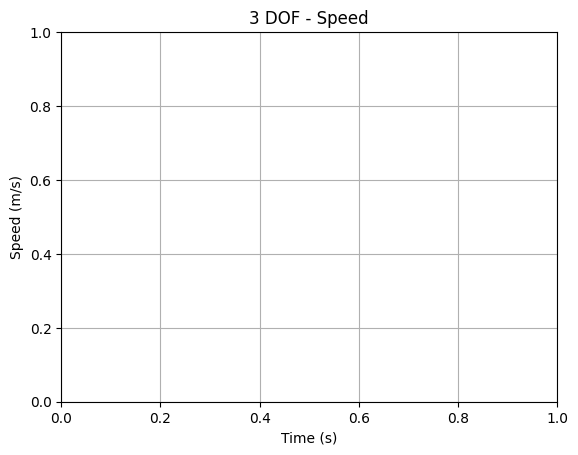

In [24]:
# Total velocity over time
flight_3dof.speed.plot()
plt.title("3 DOF - Speed")
plt.xlabel("Time (s)")
plt.ylabel("Speed (m/s)")
plt.grid(True)
plt.show()

## Part 3: Comparison of 3 DOF vs 6 DOF Results

Now let's compare key metrics between the two simulation approaches.

### 3.1 Trajectory Comparison

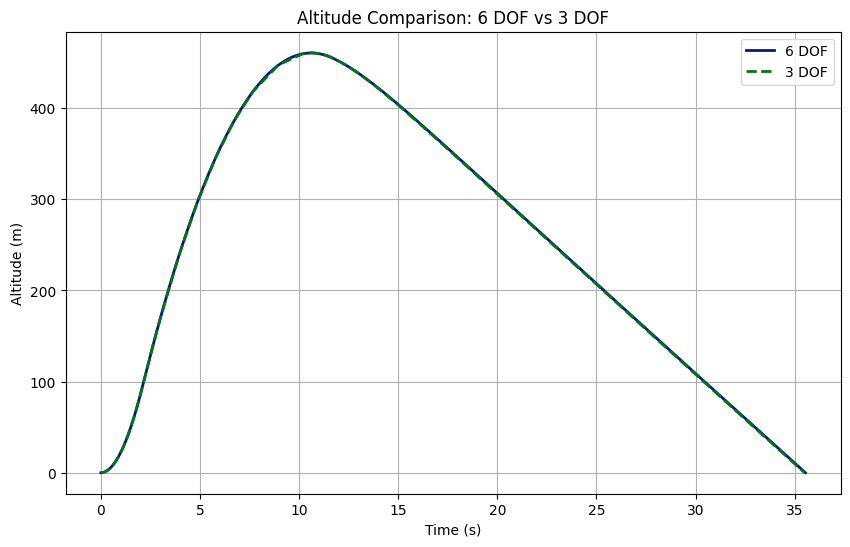

In [25]:
# Compare altitude profiles
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(flight_6dof.altitude[:, 0], flight_6dof.altitude[:, 1], label="6 DOF", linewidth=2)
ax.plot(flight_3dof.altitude[:, 0], flight_3dof.altitude[:, 1], label="3 DOF", linewidth=2, linestyle="--")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Altitude (m)")
ax.set_title("Altitude Comparison: 6 DOF vs 3 DOF")
ax.legend()
ax.grid(True)
plt.show()

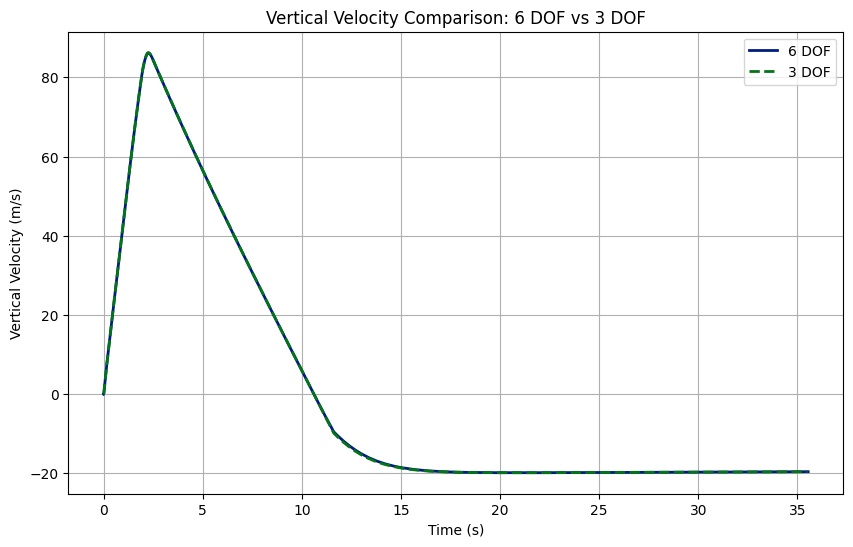

In [26]:
# Compare vertical velocity profiles
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(flight_6dof.vz[:, 0], flight_6dof.vz[:, 1], label="6 DOF", linewidth=2)
ax.plot(flight_3dof.vz[:, 0], flight_3dof.vz[:, 1], label="3 DOF", linewidth=2, linestyle="--")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Vertical Velocity (m/s)")
ax.set_title("Vertical Velocity Comparison: 6 DOF vs 3 DOF")
ax.legend()
ax.grid(True)
plt.show()

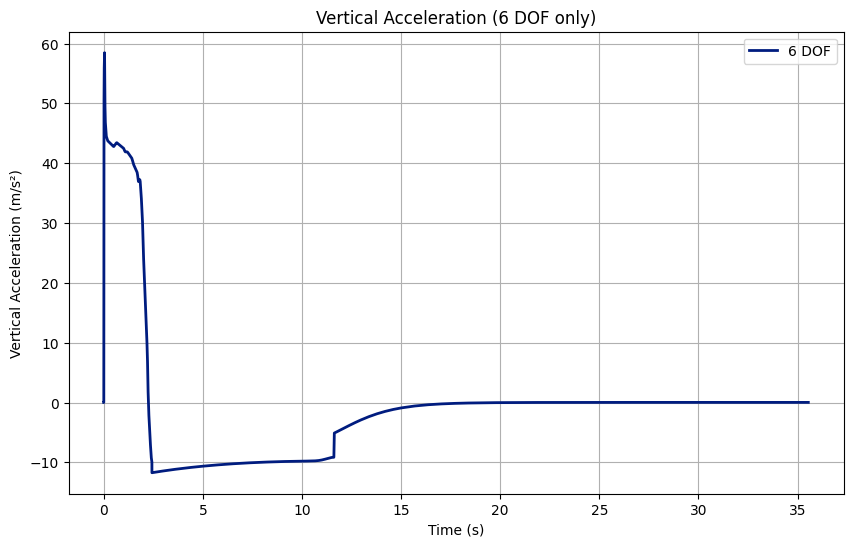

In [27]:
# Note: Vertical acceleration comparison is skipped as
# 3 DOF post-processing is not fully supported
# The 6 DOF acceleration plot is shown below for reference
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(flight_6dof.az[:, 0], flight_6dof.az[:, 1], label="6 DOF", linewidth=2)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Vertical Acceleration (m/s²)")
ax.set_title("Vertical Acceleration (6 DOF only)")
ax.legend()
ax.grid(True)
plt.show()

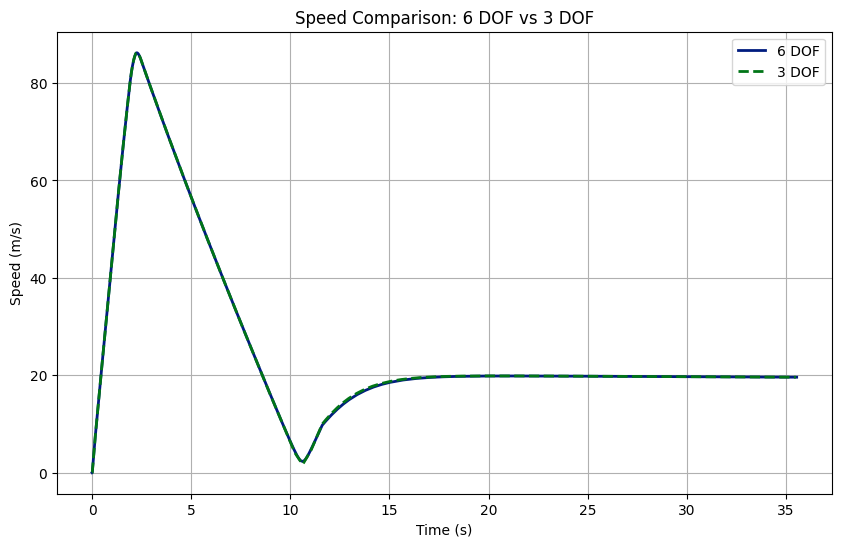

In [28]:
# Compare speed profiles
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(flight_6dof.speed[:, 0], flight_6dof.speed[:, 1], label="6 DOF", linewidth=2)
ax.plot(flight_3dof.speed[:, 0], flight_3dof.speed[:, 1], label="3 DOF", linewidth=2, linestyle="--")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Speed (m/s)")
ax.set_title("Speed Comparison: 6 DOF vs 3 DOF")
ax.legend()
ax.grid(True)
plt.show()

### 3.2 Ground Track Comparison

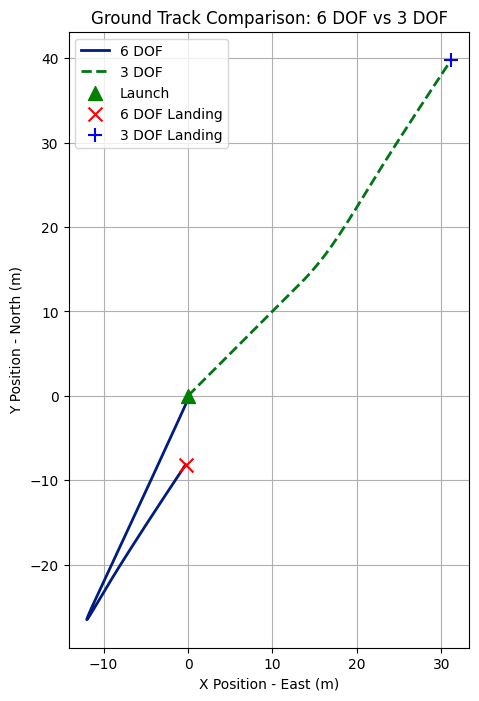

In [29]:
# Compare ground tracks (X-Y plane)
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(flight_6dof.x[:, 1], flight_6dof.y[:, 1], label="6 DOF", linewidth=2)
ax.plot(flight_3dof.x[:, 1], flight_3dof.y[:, 1], label="3 DOF", linewidth=2, linestyle="--")

# Mark launch and landing points
ax.scatter([0], [0], color="green", s=100, marker="^", label="Launch", zorder=5)
ax.scatter([flight_6dof.x_impact], [flight_6dof.y_impact], color="red", s=100, marker="x", label="6 DOF Landing", zorder=5)
ax.scatter([flight_3dof.x_impact], [flight_3dof.y_impact], color="blue", s=100, marker="+", label="3 DOF Landing", zorder=5)

ax.set_xlabel("X Position - East (m)")
ax.set_ylabel("Y Position - North (m)")
ax.set_title("Ground Track Comparison: 6 DOF vs 3 DOF")
ax.legend()
ax.grid(True)
ax.set_aspect('equal')
plt.show()

### 3.3 Key Metrics Comparison Table

In [30]:
# Extract key metrics
# Note: max_acceleration is not available for 3 DOF due to post-processing limitations
metrics_6dof = {
    "Apogee (AGL)": flight_6dof.apogee - env.elevation,
    "Time to Apogee": flight_6dof.apogee_time,
    "Max Velocity": flight_6dof.max_speed,
    "Impact X": flight_6dof.x_impact,
    "Impact Y": flight_6dof.y_impact,
    "Impact Velocity": flight_6dof.impact_velocity,
    "Flight Duration": flight_6dof.t_final,
}

metrics_3dof = {
    "Apogee (AGL)": flight_3dof.apogee - env.elevation,
    "Time to Apogee": flight_3dof.apogee_time,
    "Max Velocity": flight_3dof.max_speed,
    "Impact X": flight_3dof.x_impact,
    "Impact Y": flight_3dof.y_impact,
    "Impact Velocity": flight_3dof.impact_velocity,
    "Flight Duration": flight_3dof.t_final,
}

In [31]:
# Print comparison table
print("=" * 80)
print("COMPARISON: 6 DOF vs 3 DOF Flight Simulation")
print("=" * 80)
print(f"{'Metric':<25} {'6 DOF':>15} {'3 DOF':>15} {'Difference':>15} {'Diff %':>10}")
print("-" * 80)

for key in metrics_6dof.keys():
    val_6dof = metrics_6dof[key]
    val_3dof = metrics_3dof[key]
    
    if val_6dof is not None and val_3dof is not None:
        diff = val_3dof - val_6dof
        diff_pct = (diff / val_6dof * 100) if val_6dof != 0 else 0
        print(f"{key:<25} {val_6dof:>15.2f} {val_3dof:>15.2f} {diff:>15.2f} {diff_pct:>9.2f}%")
    else:
        print(f"{key:<25} {'N/A':>15} {'N/A':>15} {'N/A':>15} {'N/A':>10}")

print("=" * 80)

COMPARISON: 6 DOF vs 3 DOF Flight Simulation
Metric                              6 DOF           3 DOF      Difference     Diff %
--------------------------------------------------------------------------------
Apogee (AGL)                       460.55          460.85            0.30      0.07%
Time to Apogee                      10.61           10.61            0.00      0.00%
Max Velocity                        86.22           86.23            0.01      0.01%
Impact X                            -0.29           31.18           31.47 -10989.41%
Impact Y                            -8.15           39.81           47.96   -588.39%
Impact Velocity                    -19.57          -19.57            0.00     -0.00%
Flight Duration                     35.54           35.50           -0.04     -0.12%


### 3.4 Detailed Numerical Comparison

In [32]:
# Apogee comparison
apogee_6dof = flight_6dof.apogee - env.elevation
apogee_3dof = flight_3dof.apogee - env.elevation

print("Apogee (AGL)")
print(f"6 DOF: {apogee_6dof:.2f} m")
print(f"3 DOF: {apogee_3dof:.2f} m")
diff = abs(apogee_6dof - apogee_3dof)
print(f"Absolute difference: {diff:.2f} m")
print(f"Relative difference: {diff / apogee_6dof * 100:.2f} %")

Apogee (AGL)
6 DOF: 460.55 m
3 DOF: 460.85 m
Absolute difference: 0.30 m
Relative difference: 0.07 %


In [33]:
# Max velocity comparison
print("\nMax Velocity")
print(f"6 DOF: {flight_6dof.max_speed:.2f} m/s")
print(f"3 DOF: {flight_3dof.max_speed:.2f} m/s")
velocity_error = flight_3dof.max_speed - flight_6dof.max_speed
print(f"Absolute difference: {velocity_error:.2f} m/s")
print(f"Relative difference: {abs(velocity_error) / flight_6dof.max_speed * 100:.2f} %")


Max Velocity
6 DOF: 86.22 m/s
3 DOF: 86.23 m/s
Absolute difference: 0.01 m/s
Relative difference: 0.01 %


In [34]:
# Max acceleration comparison
# Note: max_acceleration is not available for 3 DOF simulations
# due to post-processing limitations in the current implementation
print("\nMax Acceleration (6 DOF only)")
print(f"6 DOF: {flight_6dof.max_acceleration:.2f} m/s²")
print("3 DOF: Not available (post-processing not supported)")


Max Acceleration (6 DOF only)
6 DOF: 58.47 m/s²
3 DOF: Not available (post-processing not supported)


In [35]:
# Landing coordinates comparison
print("\nLanding Coordinates")
print(f"6 DOF: X = {flight_6dof.x_impact:.2f} m, Y = {flight_6dof.y_impact:.2f} m")
print(f"3 DOF: X = {flight_3dof.x_impact:.2f} m, Y = {flight_3dof.y_impact:.2f} m")

# Calculate landing distance difference
landing_dist_6dof = np.sqrt(flight_6dof.x_impact**2 + flight_6dof.y_impact**2)
landing_dist_3dof = np.sqrt(flight_3dof.x_impact**2 + flight_3dof.y_impact**2)
distance_between_landings = np.sqrt((flight_6dof.x_impact - flight_3dof.x_impact)**2 + 
                                     (flight_6dof.y_impact - flight_3dof.y_impact)**2)

print(f"\nLanding distance from launch:")
print(f"6 DOF: {landing_dist_6dof:.2f} m")
print(f"3 DOF: {landing_dist_3dof:.2f} m")
print(f"Distance between landing points: {distance_between_landings:.2f} m")


Landing Coordinates
6 DOF: X = -0.29 m, Y = -8.15 m
3 DOF: X = 31.18 m, Y = 39.81 m

Landing distance from launch:
6 DOF: 8.16 m
3 DOF: 50.57 m
Distance between landing points: 57.36 m


In [36]:
# Flight time comparison
print("\nFlight Duration")
print(f"6 DOF: {flight_6dof.t_final:.2f} s")
print(f"3 DOF: {flight_3dof.t_final:.2f} s")
time_diff = abs(flight_6dof.t_final - flight_3dof.t_final)
print(f"Absolute difference: {time_diff:.2f} s")


Flight Duration
6 DOF: 35.54 s
3 DOF: 35.50 s
Absolute difference: 0.04 s


## Summary and Conclusions

This notebook demonstrated:

1. **3 DOF Simulation**: Using `PointMassRocket` to create a simplified point-mass model of the Bella Lui rocket.

2. **6 DOF Simulation**: Using the full `Rocket` class with complete aerodynamic surfaces and rotational dynamics.

3. **Comparison**: The key differences between 3 DOF and 6 DOF simulations:
   - 3 DOF is faster computationally as it ignores rotational dynamics
   - 6 DOF provides more accurate results when rotational effects are significant
   - For high-stability rockets with minimal rotational effects, 3 DOF can provide reasonable estimates

The differences observed are primarily due to:
- Lift forces generated by fins and nose cone (present only in 6 DOF)
- Angle of attack effects (present only in 6 DOF)
- Rotational dynamics affecting the trajectory (present only in 6 DOF)